In [107]:
### Import modules
import fileinput
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
from scipy.optimize import curve_fit
from scipy.spatial import KDTree
import matplotlib as mpl
import matplotlib.pyplot as plt
import time
cwd = os.getcwd()
itop=cwd.find("cgshells")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)


rcut = 1.9
skipsteps = 100000 # only calculate if timestep is divisible by skipsteps
txtdir = f"jobs/dynamics2D/distributions"

ushell = rm.load_class(version,"curvamer2d","ushell")

In [108]:

def find_midlayer_pt(result,frame):
    nshells = np.max(result.dump_mol)    # number of molecules in simulation
    molatoms = result.natoms/nshells    # number of atoms per molecule
    box_x = result.xhi - result.xlo
    box_y = result.yhi - result.ylo
    rshift = 0.5*np.array(box_x,box_y)
    
    ri = []
    vi = []
    for i in np.arange(nshells):
        mol = i+1
        aid1 = int(molatoms/4 + (mol - 1)*molatoms)    # id of middle-most atom in bottom layer 
        aid2 = int(3*molatoms/4 + (mol - 1)*molatoms)    # id of middle-most atom in bottom layer 
        mask = (result.dump_mol[frame]==mol)    # molecule mask
        a1mask = (result.dump_id[frame][mask]==aid1)
        a2mask = (result.dump_id[frame][mask]==aid2)
        r1 = np.array([result.dump_x[frame][mask][a1mask][0], # position of bottom atom
                       result.dump_y[frame][mask][a1mask][0]])
        r2 = np.array([result.dump_x[frame][mask][a2mask][0],    # position of top atom
               result.dump_y[frame][mask][a2mask][0]])
        r12 = r2 - r1 - 2*rshift * np.floor( (r2-r1)/(2*rshift) + 0.5)  # displacement vector (min image convention)
        zdist = np.sqrt(np.sum((r12)**2))
        vmol = (r12)/zdist    # molecule orientation vector
        rmol = r1 + 0.5*zdist*vmol    # position of molecule center
        # make sure molecule centers are in sim box
        if rmol[0]>result.xhi:
            rmol[0] = rmol[0]-box_x
        elif rmol[0]<result.xlo:
            rmol[0] = rmol[0]+box_x  
        if rmol[1]>result.yhi:
            rmol[1] = rmol[1]-box_y
        elif rmol[1]<result.ylo:
            rmol[1] = rmol[1]+box_y 
        ri.append(rmol.tolist())
        vi.append(vmol.tolist())
    return np.array(ri), np.array(vi)

def find_stacks(result,frame,rcut):
    # returns list of aggregate stacks
    #       list where each item is a list corresponding to one stack
    #       each stack list contains molecule ids for each molecule in that stack
    #       list of ids is in order from bottom to top of stack
    # result must have read dumpfile already

    nshells = int(np.max(result.dump_mol))
    box_x = result.xhi - result.xlo
    box_y = result.yhi - result.ylo
    rshift = 0.5*np.array(box_x,box_y)    # shift points so that box starts at (0,0)
    rm, vm = find_midlayer_pt(result,frame)
    tree = KDTree(rm+rshift,boxsize=2*rshift)
    
    done = set()
    aggs = []

    for i in range(nshells):
        if i in done:
            continue

        stack = [i]
        done.add(i)

        # ---- forward (top of stack) ----
        current = i
        while True:
            neighbors = tree.query_ball_point((rm+rshift)[current], rcut)

            candidates = []
            for k in neighbors:
                if k in done or k == current:
                    continue
                if np.dot(vm[current], vm[k]) <= 0:
                    continue

                djk = rm[k] - rm[current] - 2*rshift * np.floor((rm[k]-rm[current])/(2*rshift) + 0.5)
                proj = np.dot(djk, vm[current])

                if proj > 0:
                    candidates.append((proj, k))

            if not candidates:
                break

            # pick closest along direction
            _, next_k = max(candidates)

            stack.append(next_k)
            done.add(next_k)
            current = next_k

        # ---- backward (bottom of stack) ----
        current = i
        while True:
            neighbors = tree.query_ball_point((rm+rshift)[current], rcut)

            candidates = []
            for k in neighbors:
                if k in done or k == current:
                    continue
                if np.dot(vm[current], vm[k]) <= 0:
                    continue

                djk = rm[k] - rm[current] - 2*rshift * np.floor((rm[k]-rm[current])/(2*rshift) + 0.5)
                proj = np.dot(djk, vm[current])

                if proj < 0:
                    candidates.append((proj, k))

            if not candidates:
                break

            _, next_k = min(candidates)

            stack.insert(0, next_k)
            done.add(next_k)
            current = next_k

        aggs.append(stack)
            
    return aggs

def intershell_adhesion(result,frame,meta,molid1,molid2,rshift):
    """
    Calculate adhesive energy between two shells from trajectory file.
    Must have read dump file into result instance first.
    result: instance of ReadSim
    frame: frame to analyze
    meta: metadata (must be in dictionary form)
    molid: lammps molecule id of shell (starts from 1)
    rshift: displacement vector from bottom left corner to center of sim box
            needed for determining distances according to minimum image convention
    """
    
    pair_ints = meta["particle"]["interactions"]["pair_ints"]
    soft_ints = meta["particle"]["interactions"]["soft_ints"]
    sigma = meta["particle"]["interactions"]["sigma"]
    epsilon = meta["particle"]["interactions"]["epsilon"]
    shift = meta["particle"]["interactions"]["shift"]
    ljcut = meta["particle"]["interactions"]["ljcut"]
    wcacut = meta["particle"]["interactions"]["wcacut"]
    if soft_ints == 0:
        softsigma = 0
        softepsilon = 0
        softshift = 0
        softcut = 0
    else:
        softsigma = meta["particle"]["interactions"]["softsigma"]
        softepsilon = meta["particle"]["interactions"]["softepsilon"]
        softshift = meta["particle"]["interactions"]["softshift"]
        softcut = meta["particle"]["interactions"]["softcut"]
    
    mask1 = (result.dump_mol[frame]==molid1)
    mask2 = (result.dump_mol[frame]==molid2)
    type1list = result.dump_type[frame][mask1]
    type2list = result.dump_type[frame][mask2]
    x1list = result.dump_x[frame][mask1]
    x2list = result.dump_x[frame][mask2]
    y1list = result.dump_y[frame][mask1]
    y2list = result.dump_y[frame][mask2]
    
    list1len = len(type1list)
    list2len = len(type2list)
    
    if pair_ints == "1patch":
        pair_flag = 1
    if pair_ints == "patchy":
        pair_flag = 3
    
    return ushell(list1len,list2len,type1list,type2list,x1list,x2list,y1list,y2list,rshift,
          pair_flag,soft_ints,sigma,epsilon,shift,ljcut,wcacut,softsigma,softepsilon,softshift,softcut)

def find_stacks_adh(aggs,result,frame,meta,rshift):
    aggs_adh = []    # adhesive energy between shells in stacks (similar structure to aggs - bonds from bottom up of each stack)

    for i in range(len(aggs)):
        stacklist = aggs[i]
        stacksize = len(aggs[i])
        adhesivebonds = []

        for j in range(len(stacklist)-1):
            molidcenter = stacklist[j] + 1    # lammps id of mol

            # adhesive energy with shell above
            if j < (stacksize-1):
                molidtop = stacklist[j+1] + 1    # lammps id of mol above in stack
                eadhtop = intershell_adhesion(result,frame,meta,molidcenter,molidtop,rshift)
            else:
                eadhtop = 0

            adhesivebonds.append(eadhtop)

        #     # adhesive energy with shell below 
        #     if j != 0:
        #         molidbot = stacklist[j-1] + 1    # lammps id of mol below stack
        #         eadhbot = intershell_adhesion(result,frame,meta,molidcenter,molidbot,rshift)
        #     else:
        #         eadhbot = 0

        aggs_adh.append(adhesivebonds)
        
    return aggs_adh

def split_substacks(aggs,aggs_adh,ethresh):
    
    """Split substacks up if intershell adhesive energy is above ethresh (a negative quantity)"""
    
    stacks = []
    stacks_adh = []

    for i in range(len(aggs)):
        stack = aggs[i]
        stack_adh = aggs_adh[i]

        substacks = 1
        istart = [0]
        if len(stack_adh)>0:
            for b in range(len(stack_adh)):
                if stack_adh[b] > ethresh:
                    substacks += 1
                    istart.append(b+1)
            istart.append(b+2)

            for j in range(substacks):
                stacks.append(stack[ istart[j]:istart[j+1] ] )
                stacks_adh.append(stack_adh[ istart[j]:istart[j+1]-1])
        else:
            stacks.append(stack)
            stacks_adh.append(stack_adh)
    
    return stacks, stacks_adh

def count_stacks(aggs):
    sizes = []
    for stack in aggs:
        sizes.append(len(stack))
    sizes = np.array(sizes)
    maxsize = np.max(sizes)
    (hits, binedges, p) = plt.hist(sizes,bins=np.arange(0.5,maxsize+1.5,1))
    
    return (hits, maxsize)


def write_dists(simpath):

    tsteps = []
    hits = []
    maxsize = 0
    meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
    nruns = meta['logistics']['run_counter']
    wx = meta['particle']['geometry']['wx']
    t0 = meta['particle']['geometry']['t0']
    Nbeads = meta['particle']['geometry']['Nbeads']
    r0 = meta['particle']['geometry']['r0']
    nshells = meta['simulation']['nshells']
    sigma = meta['particle']['interactions']['sigma']
    pair_ints = meta['particle']['interactions']['pair_ints']
    soft_ints = meta['particle']['interactions']['soft_ints']
    kh = meta['particle']['elasticity']['kh']
    phi = meta['simulation']['phi']
    kT = meta['simulation']['Tstart']
    damp = meta['simulation']['Tdamp']
    if r0 == "flat":
        txtfilename = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}-ethresh-{np.abs(ethresh):0.3f}.txt"
    else:
        txtfilename = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0:0.5f}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}-ethresh-{np.abs(ethresh):0.3f}.txt"
    # loop over all trajectory files in this directory
    for ni in np.arange(1,nruns+1,1):
        tr1 = time.time()
        print(f"Reading dumpfile trajectory{ni}.dump.gz ...")
        result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
        result.read_dump(dumpname=f"trajectory{ni}.dump.gz",readall=True)
        tr2 = time.time()
        print(f"    Done. {rm.convert_time(tr2-tr1)}")
        box_x = result.xhi - result.xlo
        box_y = result.yhi - result.ylo
        rshift = 0.5*np.array(box_x,box_y)
        # loop over frames
        print("Finding stacks ...")
        for fi in np.arange(0,result.nframes):
            if (result.tsteps[fi]%skipsteps) == 0:
                try:
                    tstep_fi = result.tsteps[fi]
                    aggs = find_stacks(result,fi,rcut)
                    aggs_adh = find_stacks_adh(aggs,result,fi,meta,rshift)
                    stacks, stacks_adh = split_substacks(aggs,aggs_adh,ethresh)
                    (hits_fi, maxsize_fi) = count_stacks(stacks)
                    if maxsize_fi > maxsize:
                        maxsize = maxsize_fi
                    hits.append(hits_fi.tolist())
                    tsteps.append(tstep_fi)
                    print(f"Step = {tstep_fi}")
                except:
                    #pass
                    tstep_fi = result.tsteps[fi]
                    print(f"ERROR with Step = {tstep_fi}")

    # format text file contents for this simulation (add zeros for missing stack counts)
    darray = np.zeros([len(tsteps),maxsize+1],int)
    darray[:,0] = tsteps
    for i in np.arange(len(hits)):
        for j in np.arange(len(hits[i])):
            darray[i,j+1] = hits[i][j]

    # write to text file
    np.savetxt(f"{PROJECT_ROOT}/{txtdir}/{txtfilename}", darray, fmt="%d")


def maintest():
    t1 = time.time()
    # fetch paths to simulation directories for job (feed simpath txt file as argument)
    simpaths = [line.rstrip('\n') for line in fileinput.input()]
    i = 0
    for simpath in simpaths:
        if i == 0:
            write_dists(simpath)
        i += 1
    t2 = time.time()
    print(rm.convert_time(t2-t1))

def main():
    t1 = time.time()
    # fetch paths to simulation directories for job (feed simpath txt file as argument)
    simpaths = [line.rstrip('\n') for line in fileinput.input()]
    for simpath in simpaths:
        write_dists(simpath)
    t2 = time.time()
    print(rm.convert_time(t2-t1))

def mainclustertest():
    nnodes = 1
    ncpus = 1
    mem = 30 #GB
    partition = "cpu-preempt"
    tlim_hrs = 2
    tlim_min = 0
    computer = "unity"

    sbatchdir = f"{PROJECT_ROOT}/jobs/dynamics2D/sbatch_dists"

    if not os.path.exists(sbatchdir):
        os.makedirs(sbatchdir)

    simpaths = [line.rstrip('\n') for line in fileinput.input()]
    i = 0
    for simpath in simpaths:
        if i == 0:
            meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
            # nruns = meta['logistics']['run_counter']
            wx = meta['particle']['geometry']['wx']
            t0 = meta['particle']['geometry']['t0']
            Nbeads = meta['particle']['geometry']['Nbeads']
            r0 = meta['particle']['geometry']['r0']
            nshells = meta['simulation']['nshells']
            sigma = meta['particle']['interactions']['sigma']
            pair_ints = meta['particle']['interactions']['pair_ints']
            soft_ints = meta['particle']['interactions']['soft_ints']
            kh = meta['particle']['elasticity']['kh']
            phi = meta['simulation']['phi']
            kT = meta['simulation']['Tstart']
            damp = meta['simulation']['Tdamp']
            if r0 == "flat":
                shname = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}"
            else:
                shname = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0:0.5f}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}"

            # write_dists(simpath)
            sbatchcontents = f"""#!/bin/bash
#SBATCH -N {nnodes} # Number of Nodes
#SBATCH -n {ncpus} # Number of Tasks (cpus)
#SBATCH --mem={mem}G # Requested Memory
#SBATCH -p {partition} # Partition
#SBATCH --constraint=mpi
#SBATCH -t {tlim_hrs:02d}:{tlim_min:02d}:00 # Job time limit
#SBATCH -o {sbatchdir}/{shname}-%j.out # %j = job ID

### load modules
{rm.cluster_modules(computer)}

python3 {PROJECT_ROOT}/tools/stack_distributions.py {simpath} {rcut} {skipsteps} {txtdir}

"""
            ### write sbatch file
            with open(f"{sbatchdir}/{shname}.sh", "w") as f:
                f.write(sbatchcontents)

            ### submit sbatch file
            print(f"Submitting distribution job {i+1}...")
            sbatch = subprocess.run(['sbatch',f"{sbatchdir}/{shname}.sh"],universal_newlines = True)
        i += 1

def maincluster():
    nnodes = 1
    ncpus = 1
    mem = 30 #GB
    partition = "cpu-preempt"
    tlim_hrs = 2
    tlim_min = 0
    computer = "unity"

    sbatchdir = f"{PROJECT_ROOT}/jobs/dynamics2D/sbatch_dists"

    if not os.path.exists(sbatchdir):
        os.makedirs(sbatchdir)

    simpaths = [line.rstrip('\n') for line in fileinput.input()]
    i = 0
    for simpath in simpaths:
        meta = rm.read_metadata(f"{PROJECT_ROOT}/{simpath}")
        # nruns = meta['logistics']['run_counter']
        wx = meta['particle']['geometry']['wx']
        t0 = meta['particle']['geometry']['t0']
        Nbeads = meta['particle']['geometry']['Nbeads']
        r0 = meta['particle']['geometry']['r0']
        nshells = meta['simulation']['nshells']
        sigma = meta['particle']['interactions']['sigma']
        pair_ints = meta['particle']['interactions']['pair_ints']
        soft_ints = meta['particle']['interactions']['soft_ints']
        kh = meta['particle']['elasticity']['kh']
        phi = meta['simulation']['phi']
        kT = meta['simulation']['Tstart']
        damp = meta['simulation']['Tdamp']
        if r0 == "flat":
            shname = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}"
        else:
            shname = f"wx-{wx:0.3f}-t0-{t0:0.3f}-Nbeads-{Nbeads}-nshells-{nshells}-r0-{r0:0.5f}-sigma-{sigma:0.3f}-kh-{kh:0.3f}-pair_ints-{pair_ints}-soft_ints-{soft_ints}-phi-{phi:0.4f}-kT-{kT:0.4f}-damp-{damp:0.2f}"

        # write_dists(simpath)
        sbatchcontents = f"""#!/bin/bash
#SBATCH -N {nnodes} # Number of Nodes
#SBATCH -n {ncpus} # Number of Tasks (cpus)
#SBATCH --mem={mem}G # Requested Memory
#SBATCH -p {partition} # Partition
#SBATCH --constraint=mpi
#SBATCH -t {tlim_hrs:02d}:{tlim_min:02d}:00 # Job time limit
#SBATCH -o {sbatchdir}/{shname}-%j.out # %j = job ID

### load modules
{rm.cluster_modules(computer)}

python3 {PROJECT_ROOT}/tools/stack_distributions.py {simpath} {rcut} {skipsteps} {txtdir}

"""
        ### write sbatch file
        with open(f"{sbatchdir}/{shname}.sh", "w") as f:
            f.write(sbatchcontents)

        ### submit sbatch file
        print(f"Submitting distribution job {i+1}...")
        sbatch = subprocess.run(['sbatch',f"{sbatchdir}/{shname}.sh"],universal_newlines = True)
        i += 1
        
def plotperiodic(ax,x,y,rshift,dotstyle=".",color="blue"):
    """Plot periodic images of a plot
    ax: plot axis
    x: numpy array of x coordinates
    rshift: displacement vector (from botleft corner to center of image)
        if image has boundaries xlo, xhi, ylo, yhi, then rshift = 0.5*np.array([xhi-xlo,yhi-ylo])
    style: how to style periodic images (default is blue points)
    """
    
    # top, bot, right, left images
    ax.plot(x+2*rshift[0],y,f"{dotstyle}",color=color)
    ax.plot(x-2*rshift[0],y,f"{dotstyle}",color=color)
    ax.plot(x,y+2*rshift[1],f"{dotstyle}",color=color)
    ax.plot(x,y-2*rshift[1],f"{dotstyle}",color=color)
    # corners
    ax.plot(x+2*rshift[0],y+2*rshift[1],f"{dotstyle}",color=color)
    ax.plot(x-2*rshift[0],y+2*rshift[1],f"{dotstyle}",color=color)
    ax.plot(x+2*rshift[0],y-2*rshift[1],f"{dotstyle}",color=color)
    ax.plot(x-2*rshift[0],y-2*rshift[1],f"{dotstyle}",color=color)
    
    
def scatterperiodic(ax,x,y,rshift,colors,dotsize=5):
    """Plot periodic images of a plot
    ax: plot axis
    x: numpy array of x coordinates
    rshift: displacement vector (from botleft corner to center of image)
        if image has boundaries xlo, xhi, ylo, yhi, then rshift = 0.5*np.array([xhi-xlo,yhi-ylo])
    cmap: colormap
    dotsize: size of scatter points
    """
    
    # top, bot, right, left images
    ax.scatter(x+2*rshift[0],y,c=colors,s=dotsize)
    ax.scatter(x-2*rshift[0],y,c=colors,s=dotsize)
    ax.scatter(x,y+2*rshift[1],c=colors,s=dotsize)
    ax.scatter(x,y-2*rshift[1],c=colors,s=dotsize)
    # corners
    ax.scatter(x+2*rshift[0],y+2*rshift[1],c=colors,s=dotsize)
    ax.scatter(x-2*rshift[0],y+2*rshift[1],c=colors,s=dotsize)
    ax.scatter(x+2*rshift[0],y-2*rshift[1],c=colors,s=dotsize)
    ax.scatter(x-2*rshift[0],y-2*rshift[1],c=colors,s=dotsize)
    

In [52]:
### read dump file
simdir = f"/Users/kyle/Documents/Code/cgshells"
dumpname = f"trajectory10.dump.gz"
readall = True

result = ReadSim(simdir)
result.read_dump(dumpname=dumpname,readall=readall)

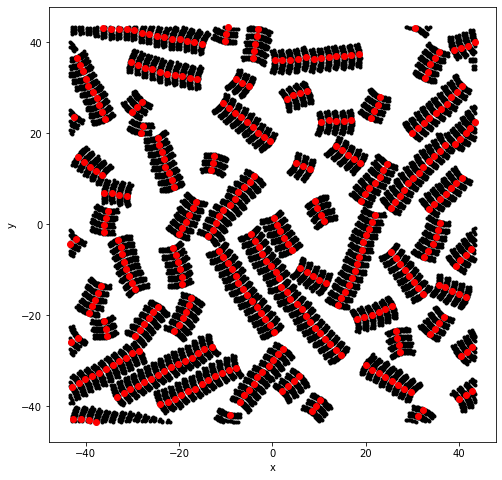

In [4]:
frame = -1

rm, vm = find_midlayer_pt(result,frame)

fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(result.dump_x[frame],result.dump_y[frame],"k.")
ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_title("Timestep {}".format(result.tsteps[frame]),fontsize=15)

ax.plot(rm[:,0],rm[:,1],"ro")

In [27]:
mol = 2
mask = (result.dump_mol[frame]==mol)
result.dump_mol[frame][mask]


array([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

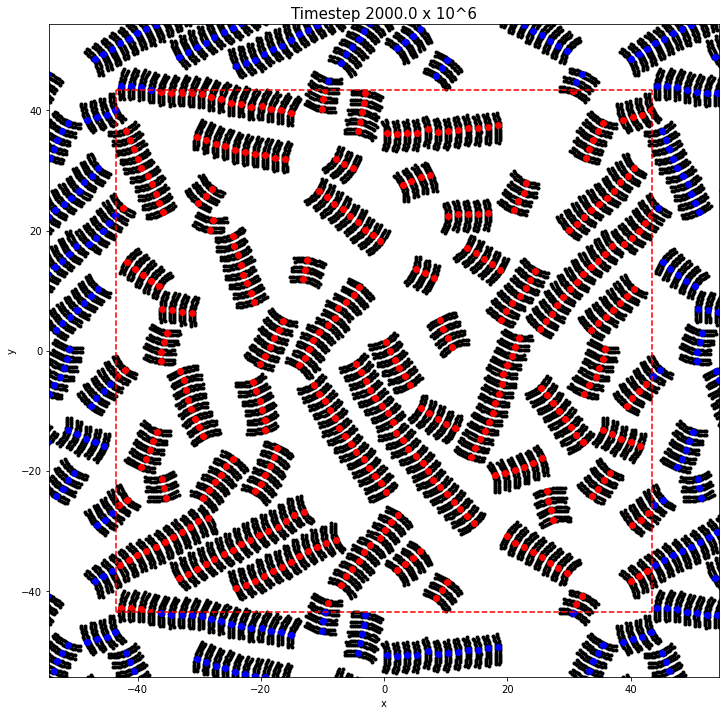

In [48]:
frame = -1
images = "True"    # show periodic images
rm, vm = find_midlayer_pt(result,frame)
rshift = np.array([0.5*(result.xhi-result.xlo),0.5*(result.yhi-result.ylo)])


dotstyle = "."

fig, ax = plt.subplots(1,1,figsize=(12,12))
ax.plot(result.dump_x[frame],result.dump_y[frame],f"k{dotstyle}")
ax.plot(rm[:,0],rm[:,1],"ro")

     
# periodic images
if images == "True":
    plotperiodic(ax,result.dump_x[frame],result.dump_y[frame],rshift,dotstyle=".",color="black")
    plotperiodic(ax,rm[:,0],rm[:,1],rshift,dotstyle="o",color="blue")


ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {} x 10^6".format(result.tsteps[frame]/1000000),fontsize=15)

if images == "True":
    # show sim box boundary for periodic images
#     ax.axis("off")
    ax.vlines(np.array([result.xlo,result.xhi]),result.ylo,result.yhi,linestyle="dashed",color="red")
    ax.hlines(np.array([result.ylo,result.yhi]),result.xlo,result.xhi,linestyle="dashed",color="red")
    impct = 0.25    # percent of periodic images to show
    ax.set_xlim((1+impct)*result.xlo,(1+impct)*result.xhi)
    ax.set_ylim((1+impct)*result.ylo,(1+impct)*result.yhi)

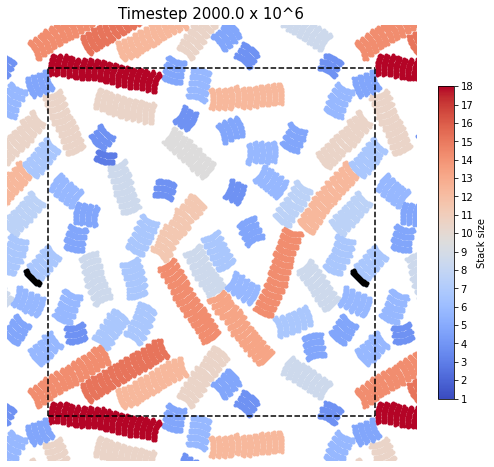

In [4]:
frame = -1
mol = 2
molmask = (result.dump_mol[frame]==mol)
rcut = 1.9
images = "True"    # show periodic images
aggs = find_stacks(result,frame,rcut)
sizes = []
for s in aggs:
    sizes.append(len(s))
sizes = np.array(sizes)
maxsize = np.max(sizes)
# maxsize = 5
rshift = np.array([0.5*(result.xhi-result.xlo),0.5*(result.yhi-result.ylo)])

# colors = ["b","r","g","c","m","y"]    # loop over colors for each stack
cmap = mpl.colormaps["coolwarm"]    # color by size
dotstyle = "."

fig, ax = plt.subplots(1,1,figsize=(8,8))
# ax.plot(result.dump_x[frame],result.dump_y[frame],f"k{dotstyle}")

# color bar
norm = mpl.colors.Normalize(vmin=1, vmax=maxsize)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required for older mpl versions

cbar = plt.colorbar(sm, ax=ax, location="right", fraction=0.035)
cbar.set_ticks(np.arange(1, maxsize+1))
cbar.set_label("Stack size")

for s in range(len(aggs)):
    stack = aggs[s]
    for i in range(len(stack)):
        mask = ( result.dump_mol[frame]==(stack[i]+1) )
#         ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask],f"{colors[s%len(colors)]}.")    
        ax.plot(result.dump_x[frame][mask],result.dump_y[frame][mask],f"{dotstyle}",color=cmap(len(stack)/maxsize))    # color by size
        
        # periodic images
        if images == "True":
            plotperiodic(ax,result.dump_x[frame][mask],result.dump_y[frame][mask],rshift,dotstyle=".",color=cmap(len(stack)/maxsize))          

ax.plot(result.dump_x[frame][molmask],result.dump_y[frame][molmask],f"{dotstyle}",color="black")    
plotperiodic(ax,result.dump_x[frame][molmask],result.dump_y[frame][molmask],rshift,dotstyle=".",color="black")          


ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {} x 10^6".format(result.tsteps[frame]/1000000),fontsize=15)

if images == "True":
    # show sim box boundary for periodic images
    ax.axis("off")
    ax.vlines(np.array([result.xlo,result.xhi]),result.ylo,result.yhi,linestyle="dashed",color="black")
    ax.hlines(np.array([result.ylo,result.yhi]),result.xlo,result.xhi,linestyle="dashed",color="black")
    impct = 0.25    # percent of periodic images to show
    ax.set_xlim((1+impct)*result.xlo,(1+impct)*result.xhi)
    ax.set_ylim((1+impct)*result.ylo,(1+impct)*result.yhi)

In [16]:
rshift

43.45112196480086

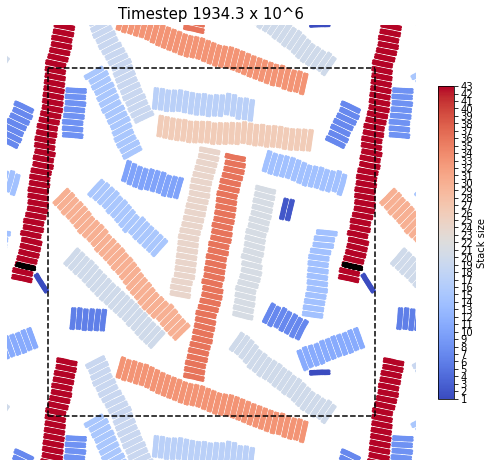

In [47]:
frame = -1
mol = 2
molmask = (result.dump_mol[frame]==mol)

nshells = int(np.max(result.dump_mol))    # number of molecules in simulation
molatoms = result.natoms/nshells    # number of atoms per molecule
box_x = result.xhi - result.xlo
box_y = result.yhi - result.ylo
rshift = 0.5*np.array([box_x,box_y])

rcut = 2.1
images = True    # show periodic images

aggs = find_stacks(result, frame, rcut)
sizes = np.array([len(s) for s in aggs])
maxsize = np.max(sizes)

cmap = mpl.colormaps["coolwarm"]
norm = mpl.colors.Normalize(vmin=1, vmax=maxsize)

# --- map molecule to stack size ---
mol_to_size = np.zeros(nshells, dtype=int)
for stack in aggs:
    for m in stack:
        mol_to_size[m] = len(stack)

# --- atom-level data ---
mol_ids = np.array(result.dump_mol[frame] - 1,dtype=int)
sizes_per_particle = mol_to_size[mol_ids]

x = result.dump_x[frame]
y = result.dump_y[frame]

fig, ax = plt.subplots(1,1,figsize=(8,8))

# all shells colored by size
sc = ax.scatter(x, y, c=cmap(norm(sizes_per_particle)), s=5)
if images == True:
    scatterperiodic(ax,x,y,rshift,cmap(norm(sizes_per_particle)),dotsize=5)

# single out selected shell
x = result.dump_x[frame][molmask]
y = result.dump_y[frame][molmask]
sc = ax.scatter(x, y, c="black", s=5)
if images == True:
    scatterperiodic(ax,x,y,rshift,"black",dotsize=5)

# dotstyle = "."
# ax.plot(result.dump_x[frame][molmask],result.dump_y[frame][molmask],f"{dotstyle}",color="black")    
# plotperiodic(ax,result.dump_x[frame][molmask],result.dump_y[frame][molmask],rshift,dotstyle=dotstyle,color="black")
    
# colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.035)
cbar.set_ticks(np.arange(1, maxsize+1))
cbar.set_label("Stack size")

ax.vlines(np.array([result.xlo,result.xhi]),result.ylo,result.yhi,linestyle="dashed",color="black")
ax.hlines(np.array([result.ylo,result.yhi]),result.xlo,result.xhi,linestyle="dashed",color="black")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {} x 10^6".format(result.tsteps[frame]/1000000),fontsize=15)

if images == True:
    # show sim box boundary for periodic images
    ax.axis("off")
    impct = 0.25    # percent of periodic images to show
    ax.set_xlim((1+impct)*result.xlo,(1+impct)*result.xhi)
    ax.set_ylim((1+impct)*result.ylo,(1+impct)*result.yhi)

In [7]:
meta = rm.read_metadata(f"{PROJECT_ROOT}")
meta["particle"]["interactions"]

{'pair_ints': 'patchy',
 'soft_ints': 0,
 'sigma': 0.25,
 'epsilon': 0.03646936260753168,
 'shift': 0.7193844879226567,
 'ljcut': 1.25,
 'wcacut': 1.0}

In [48]:
box_x = result.xhi - result.xlo
box_y = result.yhi - result.ylo
rshift = 0.5*np.array([box_x,box_y])
meta = rm.read_metadata(f"{PROJECT_ROOT}")

rcut = 2.1
aggs = find_stacks(result, frame, rcut)
aggs_adh = []    # adhesive energy between shells in stacks (similar structure to aggs - bonds from bottom up of each stack)

for i in range(len(aggs)):
    stacklist = aggs[i]
    stacksize = len(aggs[i])
    adhesivebonds = []

    for j in range(len(stacklist)-1):
        molidcenter = stacklist[j] + 1    # lammps id of mol

        # adhesive energy with shell above
        if j < (stacksize-1):
            molidtop = stacklist[j+1] + 1    # lammps id of mol above in stack
            eadhtop = intershell_adhesion(result,frame,meta,molidcenter,molidtop,rshift)
        else:
            eadhtop = 0

        adhesivebonds.append(eadhtop)

    #     # adhesive energy with shell below 
    #     if j != 0:
    #         molidbot = stacklist[j-1] + 1    # lammps id of mol below stack
    #         eadhbot = intershell_adhesion(result,frame,meta,molidcenter,molidbot,rshift)
    #     else:
    #         eadhbot = 0
    
    aggs_adh.append(adhesivebonds)

In [55]:
s

7

In [54]:
emin = 0
emax = -1
avg = 0
nbonds = 0
ebonds = []
for s in aggs_adh:
    for b in s:
        if len(s)>0:
            nbonds += 1
            avg += b
            ebonds.append(b)
            if b<emin:
                emin = b
            if b>emax:
                emax = b
print(f"emin = {emin}")
print(f"emax = {emax}")
print(f"eavg = {avg/nbonds}")

emin = -0.9557473548495835
emax = -0.4021799014070265
eavg = -0.8138368789341601


Text(0, 0.5, 'Hits')

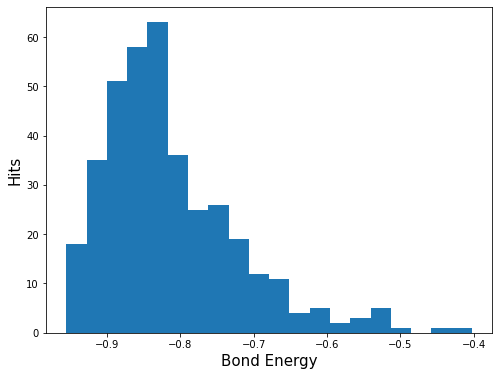

In [55]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.hist(ebonds,bins=20)
ax.set_xlabel("Bond Energy",fontsize = 15)
ax.set_ylabel("Hits",fontsize = 15)

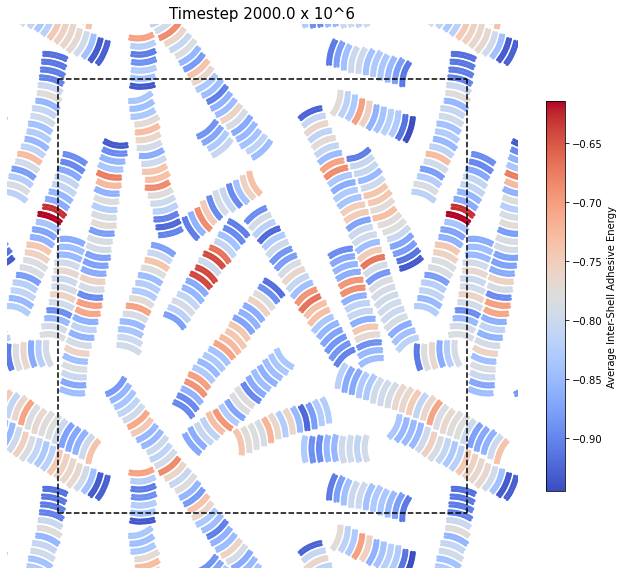

In [53]:
frame = -1
rcut = 2.1

mol = 2
molmask = (result.dump_mol[frame]==mol)

nshells = int(np.max(result.dump_mol))    # number of molecules in simulation
molatoms = result.natoms/nshells    # number of atoms per molecule
box_x = result.xhi - result.xlo
box_y = result.yhi - result.ylo
rshift = 0.5*np.array([box_x,box_y])

images = True    # show periodic images

meta = rm.read_metadata(f"{PROJECT_ROOT}")

aggs = find_stacks(result, frame, rcut)
aggs_adh = find_stacks_adh(aggs,result,frame,meta,rshift)

# --- map molecule to stack size ---
mol_to_adh = np.zeros(nshells)
for s in range(len(aggs)):
    stack = aggs[s]
    stackbonds = aggs_adh[s]
    for m in range(len(stack)):
        mol = stack[m]
        if len(stackbonds) > 0:
            if m == 0:
                mol_to_adh[mol] = stackbonds[m]
            elif m == (len(stack) - 1):
                mol_to_adh[mol] = stackbonds[m-1]
            else:
                mol_to_adh[mol] = 0.5 * (stackbonds[m] + stackbonds[m-1])

# --- atom-level data ---
mol_ids = np.array(result.dump_mol[frame] - 1,dtype=int)
adh_per_particle = mol_to_adh[mol_ids]

x = result.dump_x[frame]
y = result.dump_y[frame]
cmap = mpl.colormaps["coolwarm"]
norm = mpl.colors.Normalize(vmin=np.min(adh_per_particle), vmax=np.max(adh_per_particle))

fig, ax = plt.subplots(1,1,figsize=(10,10))

# all shells colored by size
sc = ax.scatter(x, y, c=cmap(norm(adh_per_particle)), s=5)
if images == True:
    scatterperiodic(ax,x,y,rshift,cmap(norm(adh_per_particle)),dotsize=5)

# single out selected shell
# x = result.dump_x[frame][molmask]
# y = result.dump_y[frame][molmask]
# sc = ax.scatter(x, y, c="black", s=5)
# if images == True:
#     scatterperiodic(ax,x,y,rshift,"black",dotsize=5)

# colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.035)
# cbar.set_ticks(np.arange(1, maxsize+1))
cbar.set_label("Average Inter-Shell Adhesive Energy")

ax.vlines(np.array([result.xlo,result.xhi]),result.ylo,result.yhi,linestyle="dashed",color="black")
ax.hlines(np.array([result.ylo,result.yhi]),result.xlo,result.xhi,linestyle="dashed",color="black")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {} x 10^6".format(result.tsteps[frame]/1000000),fontsize=15)

if images == True:
    # show sim box boundary for periodic images
    ax.axis("off")
    impct = 0.25    # percent of periodic images to show
    ax.set_xlim((1+impct)*result.xlo,(1+impct)*result.xhi)
    ax.set_ylim((1+impct)*result.ylo,(1+impct)*result.yhi)

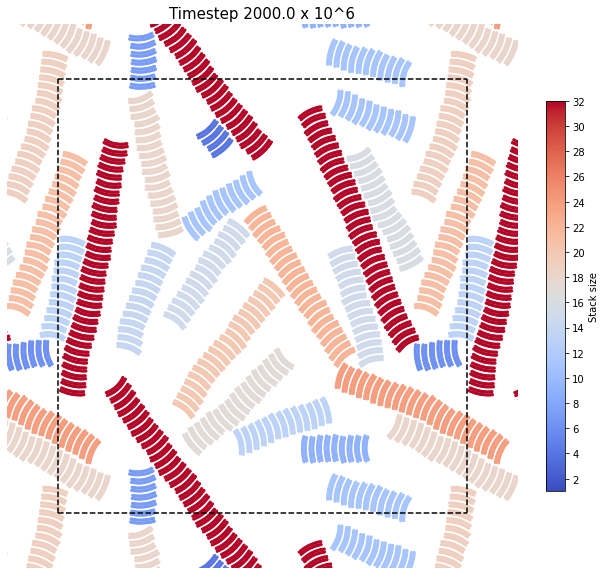

In [58]:
# frame = -2
mol = 2
molmask = (result.dump_mol[frame]==mol)

meta = rm.read_metadata(f"{PROJECT_ROOT}")

nshells = int(np.max(result.dump_mol))    # number of molecules in simulation
molatoms = result.natoms/nshells    # number of atoms per molecule
box_x = result.xhi - result.xlo
box_y = result.yhi - result.ylo
rshift = 0.5*np.array([box_x,box_y])

rcut = 2.1

images = True    # show periodic images
t1 = time.time()
aggs = find_stacks(result, frame, rcut)
t2 = time.time()
aggs_adh = find_stacks_adh(aggs,result,frame,meta,rshift)
t3 = time.time()
sizes = np.array([len(s) for s in aggs])
maxsize = np.max(sizes)

cmap = mpl.colormaps["coolwarm"]
norm = mpl.colors.Normalize(vmin=1, vmax=maxsize)

# --- map molecule to stack size ---
mol_to_size = np.zeros(nshells, dtype=int)
for stack in aggs:
    for m in stack:
        mol_to_size[m] = len(stack)

# --- atom-level data ---
mol_ids = np.array(result.dump_mol[frame] - 1,dtype=int)
sizes_per_particle = mol_to_size[mol_ids]

x = result.dump_x[frame]
y = result.dump_y[frame]

fig, ax = plt.subplots(1,1,figsize=(10,10))

# all shells colored by size
sc = ax.scatter(x, y, c=cmap(norm(sizes_per_particle)), s=5)
if images == True:
    scatterperiodic(ax,x,y,rshift,cmap(norm(sizes_per_particle)),dotsize=5)

# # single out selected shell
# x = result.dump_x[frame][molmask]
# y = result.dump_y[frame][molmask]
# sc = ax.scatter(x, y, c="black", s=5)
# if images == True:
#     scatterperiodic(ax,x,y,rshift,"black",dotsize=5)
 
# colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.035)
cbar.set_ticks(np.arange(2, maxsize+1,2))
cbar.set_label("Stack size")

ax.vlines(np.array([result.xlo,result.xhi]),result.ylo,result.yhi,linestyle="dashed",color="black")
ax.hlines(np.array([result.ylo,result.yhi]),result.xlo,result.xhi,linestyle="dashed",color="black")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {} x 10^6".format(result.tsteps[frame]/1000000),fontsize=15)

if images == True:
    # show sim box boundary for periodic images
    ax.axis("off")
    impct = 0.25    # percent of periodic images to show
    ax.set_xlim((1+impct)*result.xlo,(1+impct)*result.xhi)
    ax.set_ylim((1+impct)*result.ylo,(1+impct)*result.yhi)

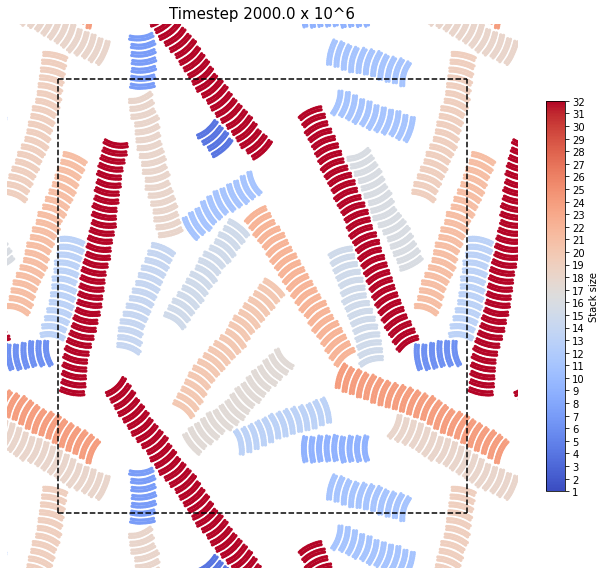

In [106]:
eadh = -1
ethresh = 0.4*eadh

t4 = time.time()
stacks, stacks_adh = split_substacks(aggs,aggs_adh,ethresh)
t5 = time.time()
    
sizes = np.array([len(s) for s in stacks])
maxsize = np.max(sizes)

cmap = mpl.colormaps["coolwarm"]
norm = mpl.colors.Normalize(vmin=1, vmax=maxsize)

# --- map molecule to stack size ---
mol_to_size = np.zeros(nshells, dtype=int)
for stack in stacks:
    for m in stack:
        mol_to_size[m] = len(stack)

# --- atom-level data ---
mol_ids = np.array(result.dump_mol[frame] - 1,dtype=int)
sizes_per_particle = mol_to_size[mol_ids]

x = result.dump_x[frame]
y = result.dump_y[frame]

fig, ax = plt.subplots(1,1,figsize=(10,10))

# all shells colored by size
sc = ax.scatter(x, y, c=cmap(norm(sizes_per_particle)), s=5)
if images == True:
    scatterperiodic(ax,x,y,rshift,cmap(norm(sizes_per_particle)),dotsize=5)

# # single out selected shell
# x = result.dump_x[frame][molmask]
# y = result.dump_y[frame][molmask]
# sc = ax.scatter(x, y, c="black", s=5)
# if images == True:
#     scatterperiodic(ax,x,y,rshift,"black",dotsize=5)
 
# colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.035)
cbar.set_ticks(np.arange(1, maxsize+1))
cbar.set_label("Stack size")

ax.vlines(np.array([result.xlo,result.xhi]),result.ylo,result.yhi,linestyle="dashed",color="black")
ax.hlines(np.array([result.ylo,result.yhi]),result.xlo,result.xhi,linestyle="dashed",color="black")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Timestep {} x 10^6".format(result.tsteps[frame]/1000000),fontsize=15)

if images == True:
    # show sim box boundary for periodic images
    ax.axis("off")
    impct = 0.25    # percent of periodic images to show
    ax.set_xlim((1+impct)*result.xlo,(1+impct)*result.xhi)
    ax.set_ylim((1+impct)*result.ylo,(1+impct)*result.yhi)

(0.0, 12.0)

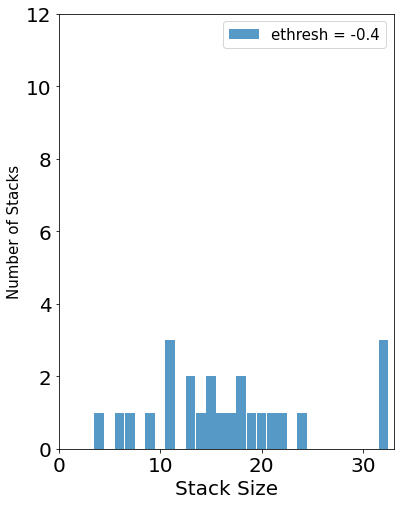

In [104]:
sizes = []
for stack in stacks:
    sizes.append(len(stack))
sizes = np.array(sizes)
maxsize = np.max(sizes)

bins = np.arange(0.5,maxsize+1.5,1)
fig, ax = plt.subplots(1,1,figsize=(6,8))
ax.hist(sizes,bins, rwidth=0.95,alpha = 0.75,label=f"ethresh = {ethresh}",log=False)
ax.set_xlabel("Stack Size",fontsize=20)
ax.set_ylabel("Number of Stacks", fontsize=15)
ax.tick_params(labelsize=20)
ax.legend(fontsize=15)
ax.set_xlim(0,33)
ax.set_ylim(0,12)

In [31]:
eadh = -1
ethresh = 0.2*eadh

# aggs = [[1],[0,10,4,2,13,20,5,4]]
# aggs_adh = [[],[-0.7,-0.1,-0.7,-0.5,-0.2,-0.8,-0.7]]

stacks = []
stacks_adh = []

for i in range(len(aggs)):
    stack = aggs[i]
    stack_adh = aggs_adh[i]
    
    substacks = 1
    istart = [0]
    if len(stack_adh)>0:
        for b in range(len(stack_adh)):
            if stack_adh[b] > ethresh:
                substacks += 1
                istart.append(b+1)
        istart.append(b+2)

        for j in range(substacks):
            stacks.append(stack[ istart[j]:istart[j+1] ] )
            stacks_adh.append(stack_adh[ istart[j]:istart[j+1]-1])
    else:
        stacks.append(stack)
        stacks_adh.append(stack_adh)
    

In [30]:
stacks

[[0],
 [1],
 [2],
 [3],
 [4],
 [5],
 [6],
 [7],
 [8],
 [9],
 [10],
 [11],
 [12],
 [13],
 [14],
 [15],
 [16],
 [17],
 [18],
 [19],
 [20],
 [21],
 [22],
 [23],
 [24],
 [25],
 [26],
 [27],
 [28],
 [29],
 [30],
 [31],
 [32],
 [33],
 [34],
 [35],
 [36],
 [37],
 [38],
 [39],
 [40],
 [41],
 [42],
 [43],
 [44],
 [45],
 [46],
 [47],
 [48],
 [49],
 [50],
 [51],
 [52],
 [53],
 [54],
 [55],
 [56],
 [57],
 [58],
 [59],
 [60],
 [61],
 [62],
 [63],
 [64],
 [65],
 [66],
 [67],
 [68],
 [69],
 [70],
 [71],
 [72],
 [73],
 [74],
 [75],
 [76],
 [77],
 [78],
 [79],
 [80],
 [81],
 [82],
 [83],
 [84],
 [85],
 [86],
 [87],
 [88],
 [149],
 [89],
 [90],
 [91],
 [92],
 [93],
 [94],
 [95],
 [96],
 [97],
 [98],
 [99],
 [100],
 [101],
 [102],
 [103],
 [104],
 [105],
 [106],
 [107],
 [108],
 [109],
 [110],
 [111],
 [112],
 [113],
 [114],
 [115],
 [116],
 [117],
 [118],
 [119],
 [120],
 [121],
 [122],
 [123],
 [124],
 [125],
 [126],
 [127],
 [128],
 [129],
 [130],
 [131],
 [132],
 [133],
 [134],
 [135],
 [136],
 [137]

In [28]:
stacks_adh

[[],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],
 [],


In [18]:
np.arange(10)[1:10]

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [58]:
mol

40

In [59]:
stackbonds[m]

-0.3443521856665747

In [52]:
mol_to_adh[mol] = 1

In [70]:
mol_to_adh[58]

-0.3452066270190981

In [20]:
stacklist

[0, 40, 30, 379, 58]

In [15]:
molidcenter

41

In [16]:
eadhtop

-0.3443521856665747

In [17]:
eadhbot

-0.41064620081529385

In [51]:
from numba import jit